# Pseudospectral Methods, Part VIII: Topology Optimization

For one notebook we step outside the pseudospectral world and into a problem where every other
piece of machinery in this series — adjoints (Part IV), KKT inequalities and complementary
slackness (Part VII), iterative constrained optimization (Parts VI, VII) — comes together to
produce a striking visual result. This is **structural topology optimization**: given a 2D
design domain, applied loads, fixed supports, and a material-volume budget, find the material
distribution that minimizes structural compliance.

The output is an image: black where there's material, white where there isn't. The constraints:

* **PDE constraint** — the displacement field satisfies linear elasticity for the chosen
  material distribution.
* **Volume constraint** — the total amount of material is bounded above (a single global
  inequality).
* **Box constraints** — density at each element is between 0 and 1.

The number of design variables (one density per element) runs into the thousands; the number
of inequality constraints (the box bounds and the volume constraint) is even larger. This is
where adjoint sensitivity is non-negotiable — finite-difference gradients would require a
forward solve per element, taking minutes per iteration. With adjoints, one forward + one
adjoint solve per outer iteration suffices, and the whole problem completes in seconds.

We'll use a **finite-element discretization** (bilinear quadrilateral elements on a structured
grid) — that's the standard for topology optimization. The math is exactly the same KKT/adjoint
machinery; only the spatial discretization changes.

Outline:

1. Compliance, SIMP penalization, and why this problem has a "topology".
2. The 2D linear-elasticity FE solver (compact: ~30 lines).
3. Self-adjoint compliance: why $\lambda = u$, and the per-element gradient formula.
4. Optimality-criteria (OC) update: bisection on the volume-constraint multiplier.
5. Density filter: the cure for checkerboard instabilities.
6. Solving a classic cantilever beam, watching the design evolve.

In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": False, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
})

## 1. Compliance, SIMP, and topology

### Compliance

For a linear-elastic body subject to a static load $\mathbf{f}$, **compliance** is

$$
c \;=\; \mathbf{f}^\top \mathbf{u} \;=\; \mathbf{u}^\top \mathbf{K}\,\mathbf{u},
$$

where $\mathbf{K}$ is the global stiffness matrix and $\mathbf{u}$ is the displacement field
solving $\mathbf{K}\,\mathbf{u} = \mathbf{f}$. Compliance is the strain energy stored in the
body — *low compliance = stiff structure*. Minimizing compliance is the canonical
topology-optimization objective.

### SIMP penalization

We discretize the design domain into $n_\mathrm{el}$ elements. To each element $e$ we assign a
**density** $\rho_e \in [0, 1]$: $\rho_e = 1$ means full material, $\rho_e = 0$ means void. The
element stiffness matrix scales nonlinearly with density via the **Solid Isotropic Material
with Penalization** (SIMP) interpolation:

$$
\mathbf{K}_e(\rho_e) \;=\; \bigl(E_\mathrm{min} + (E_0 - E_\mathrm{min})\,\rho_e^p\bigr)\,\mathbf{K}_e^0,
$$

where $\mathbf{K}_e^0$ is the unit-density element stiffness, $E_0$ is the full Young's modulus,
$E_\mathrm{min}$ is a tiny floor (avoids singular $\mathbf{K}$ in void regions), and $p \ge 1$
is a **penalty exponent** — typically $p = 3$.

**Why $p > 1$?** Because intermediate densities $\rho_e \approx 0.5$ are physically
unrealizable (you can't have "half-material"). The SIMP exponent makes them
disproportionately *cost-ineffective*: $0.5^3 = 0.125$ stiffness for $0.5$ volume cost. The
optimizer is forced toward 0/1 designs where intermediates are unprofitable. This converts a
**discrete topology** problem (each element ∈ {void, solid}) into a **continuous design**
problem (densities ∈ [0, 1]) that gradient methods can solve, while strongly biasing the
solution toward the discrete answer.

### The full NLP

$$
\min_{\boldsymbol\rho \in [0,1]^{n_\mathrm{el}}}\; c(\boldsymbol\rho) \;=\; \mathbf{f}^\top \mathbf{u}(\boldsymbol\rho)
$$

subject to

$$
\mathbf{K}(\boldsymbol\rho)\,\mathbf{u}(\boldsymbol\rho) = \mathbf{f}, \qquad
\sum_{e} v_e\,\rho_e \;\le\; V_\mathrm{max}, \qquad
0 \le \rho_e \le 1.
$$

* $n_\mathrm{el} \sim 10^3$–$10^5$ design variables.
* 1 PDE constraint (vectorized, with $\sim 2\cdot n_\mathrm{el}$ DOFs).
* 1 volume inequality (one Lagrange multiplier).
* $2 n_\mathrm{el}$ box constraints (one Lagrange multiplier each).

Production codes hand this to MMA (the **method of moving asymptotes**, Svanberg 1987) which
is essentially active-set on the full inequality system. We'll use the simpler **optimality
criteria** update — equivalent to MMA on this self-adjoint problem and easier to read.

## 2. Bilinear-quadrilateral FE elasticity solver

Each element is a unit square with four nodes; each node has $(u_x, u_y)$ DOFs, so the element
has 8 DOFs and the element stiffness matrix $\mathbf{K}_e^0$ is $8 \times 8$. For plane stress
with Young's modulus $E = 1$ and Poisson ratio $\nu = 0.3$, $\mathbf{K}_e^0$ has a closed-form
expression (constant across all elements on a uniform grid).

We assemble the global $\mathbf{K}$ once per design iteration (it depends on $\rho$), solve
$\mathbf{K}\mathbf{u} = \mathbf{f}$, and read out compliance.

In [2]:
def element_stiffness(nu=0.3):
    '''Bilinear quad element stiffness matrix for plane stress, E = 1, unit cell.
    Standard closed-form (Cook 1995, Bendsoe & Sigmund 2003).'''
    A11 = np.array([[12, 3, -6, -3], [3, 12, 3, 0], [-6, 3, 12, -3], [-3, 0, -3, 12]])
    A12 = np.array([[-6, -3, 0, 3], [-3, -6, -3, -6], [0, -3, -6, 3], [3, -6, 3, -6]])
    B11 = np.array([[-4, 3, -2, 9], [3, -4, -9, 4], [-2, -9, -4, -3], [9, 4, -3, -4]])
    B12 = np.array([[2, -3, 4, -9], [-3, 2, 9, -2], [4, 9, 2, 3], [-9, -2, 3, 2]])
    A = np.block([[A11, A12], [A12.T, A11]]) / 24.0
    B = np.block([[B11, B12], [B12.T, B11]]) / 24.0
    return 1.0 / (1 - nu**2) * (A + nu * B)


def build_topology_problem(nelx, nely, force_node, force_dir, fixed_dofs):
    '''Set up FE assembly indices, force vector, and free-DOF mask.

    Parameters:
      nelx, nely : grid size in elements (so nodes are (nelx+1) x (nely+1))
      force_node : (i, j) node index where force is applied
      force_dir  : (fx, fy) force vector at that node
      fixed_dofs : list of global DOF indices that are fixed (Dirichlet BC)
    '''
    ndof = 2 * (nelx + 1) * (nely + 1)
    KE = element_stiffness()

    # Element-to-DOF connectivity: edofMat[e, :] gives 8 global DOF indices for element e
    nodenrs = np.arange((nely + 1) * (nelx + 1)).reshape(nelx + 1, nely + 1).T
    # Element ordering: column-major in (nelx, nely)
    edofVec = (2 * nodenrs[:-1, :-1] + 2).ravel(order="F")
    edofMat = np.tile(edofVec, (8, 1)).T + np.array([0, 1, 2 * nely + 2, 2 * nely + 3,
                                                       2 * nely, 2 * nely + 1, -2, -1])
    iK = np.kron(edofMat, np.ones((8, 1))).astype(int).ravel()
    jK = np.kron(edofMat, np.ones((1, 8))).astype(int).ravel()

    # Force vector
    f = np.zeros(ndof)
    fi, fj = force_node
    n_global = fi * (nely + 1) + fj
    f[2 * n_global    ] = force_dir[0]
    f[2 * n_global + 1] = force_dir[1]

    free_dofs = np.setdiff1d(np.arange(ndof), fixed_dofs)
    return KE, edofMat, iK, jK, f, free_dofs


def fe_solve(rho, KE, edofMat, iK, jK, f, free_dofs, p=3, Emin=1e-9, E0=1.0):
    '''Assemble K(rho) and solve K u = f.  Returns u and per-element strain energies.'''
    nel = rho.size
    sK = ((KE.ravel()[:, None] * (Emin + rho.ravel("F")**p * (E0 - Emin))).ravel(order="F"))
    K = sp.coo_matrix((sK, (iK, jK))).tocsc()
    K_ff = K[free_dofs, :][:, free_dofs]
    u = np.zeros(f.size)
    u[free_dofs] = spla.spsolve(K_ff, f[free_dofs])

    # Per-element strain energy ce = u_e^T KE u_e (used in compliance + sensitivity)
    ce = np.einsum("ei,ij,ej->e", u[edofMat], KE, u[edofMat])
    return u, ce.reshape(rho.shape, order="F")

## 3. Self-adjoint compliance and the gradient

### The adjoint setup

Compliance is $c = \mathbf{f}^\top \mathbf{u}$ subject to $\mathbf{K}(\boldsymbol\rho)\,\mathbf{u} = \mathbf{f}$.
Lagrangian:

$$
\mathcal L = \mathbf{f}^\top \mathbf{u} + \boldsymbol\lambda^\top (\mathbf{K}\mathbf{u} - \mathbf{f}).
$$

Stationarity in $\mathbf{u}$:

$$
\nabla_\mathbf{u} \mathcal L = \mathbf{f} + \mathbf{K}^\top \boldsymbol\lambda = 0
\quad\Longrightarrow\quad \mathbf{K}^\top \boldsymbol\lambda = -\mathbf{f}.
$$

Since $\mathbf{K}$ is symmetric ($\mathbf{K} = \mathbf{K}^\top$), the adjoint equation is the
same equation as the forward solve up to sign: $\mathbf{K}\boldsymbol\lambda = -\mathbf{f}$, so
$\boldsymbol\lambda = -\mathbf{u}$. **No second linear solve needed**. This is what "self-adjoint"
means: the adjoint is the negative of the state. It's special to compliance and a few other
quadratic functionals; for $\mathbf{f}^\top \mathbf{A}\,\mathbf{u}$ with general $\mathbf{A}$
you'd actually do the second solve.

### The gradient

$$
\frac{dc}{d\rho_e} = \boldsymbol\lambda^\top\!\frac{\partial \mathbf{K}}{\partial \rho_e}\mathbf{u}
= -\mathbf{u}^\top\!\frac{\partial \mathbf{K}}{\partial \rho_e}\mathbf{u}.
$$

Only one element's stiffness matrix depends on $\rho_e$, so

$$
\frac{\partial \mathbf{K}}{\partial \rho_e} = p (E_0 - E_\mathrm{min})\, \rho_e^{p-1}\,\mathbf{K}_e^0
\quad \text{(at element } e \text{, zero elsewhere)},
$$

and the gradient at element $e$ is

$$
\boxed{\;\frac{dc}{d\rho_e} \;=\; -p (E_0 - E_\mathrm{min})\,\rho_e^{p-1}\, \mathbf{u}_e^\top \mathbf{K}_e^0\, \mathbf{u}_e.\;}
$$

The quantity $\mathbf{u}_e^\top \mathbf{K}_e^0 \mathbf{u}_e$ is exactly the per-element strain
energy $c_e$ that the FE solver already returned. So the sensitivity is essentially free —
just a multiplication. This is the critical computational property that lets topology
optimization run in seconds.

## 4. Optimality-criteria update

We have a single equality (volume) and many box constraints. The reduced KKT conditions can be
solved very efficiently by an **optimality-criteria (OC) update**: at each iteration, compute
the gradient $g_e = dc/d\rho_e$, then apply the heuristic update

$$
\rho_e^\mathrm{new} = \mathrm{clip}\Bigl(\rho_e \cdot \bigl(B_e\bigr)^\eta,\; 0,\; 1\Bigr),
\quad B_e = \frac{-g_e}{\Lambda\, v_e},
$$

with **damping exponent** $\eta = 0.5$ and **move limit** to keep $|\rho^\mathrm{new} - \rho| \le 0.2$.
$\Lambda$ is the Lagrange multiplier on the volume constraint, found by **bisection** so that
$\sum_e v_e \rho_e^\mathrm{new} = V_\mathrm{max}$.

Why this works: if $-g_e > \Lambda v_e$ (improving cost faster than spending budget), increase
$\rho_e$; if smaller, decrease. The bisection on $\Lambda$ finds the precise rate at which
"cost reduction per unit volume" is balanced across all elements. This is exactly KKT
stationarity for a single linear inequality with multiplier $\Lambda$.

For problems with multiple inequalities (stress constraints, eigenvalue constraints, multiple
load cases) you'd use **MMA** instead — the OC update generalizes only to a single global
inequality.

In [3]:
def oc_update(rho, dcdrho, volume_frac, move=0.2, eta=0.5):
    '''Optimality criteria update with bisection on the volume Lagrange multiplier.'''
    l1, l2 = 1e-9, 1e9
    rho_new = rho.copy()
    while (l2 - l1) / (l1 + l2) > 1e-3:
        lmid = 0.5 * (l1 + l2)
        # B_e = -dc/drho / (lambda * v_e); v_e = 1 (unit element volume)
        B = np.maximum(1e-10, -dcdrho / lmid)
        rho_new = np.clip(np.clip(rho * np.sqrt(B),
                                  rho - move, rho + move),
                          1e-3, 1.0)
        if rho_new.sum() > volume_frac * rho.size:
            l1 = lmid
        else:
            l2 = lmid
    return rho_new


def density_filter(rho, rmin):
    '''Linear "hat" density filter: rho_e_filt = sum(w_ef * rho_f) / sum(w_ef).
    Suppresses checkerboard patterns and mesh-dependent solutions.'''
    nely, nelx = rho.shape
    # Build sparse filter matrix once; for typical rmin = 1.5 this is highly local.
    iH, jH, sH = [], [], []
    rmin_int = int(np.ceil(rmin))
    for j in range(nelx):
        for i in range(nely):
            e1 = j * nely + i
            for jj in range(max(0, j - rmin_int), min(nelx, j + rmin_int + 1)):
                for ii in range(max(0, i - rmin_int), min(nely, i + rmin_int + 1)):
                    e2 = jj * nely + ii
                    w = max(0.0, rmin - np.sqrt((i - ii)**2 + (j - jj)**2))
                    if w > 0:
                        iH.append(e1); jH.append(e2); sH.append(w)
    H = sp.coo_matrix((sH, (iH, jH))).tocsc()
    Hs = np.array(H.sum(axis=1)).ravel()
    return H, Hs

## 5. The classic cantilever beam

Set up the cantilever problem:

* Domain: $\mathrm{nelx} = 60$ wide, $\mathrm{nely} = 30$ tall (1800 elements).
* Boundary: left edge fully fixed (all DOFs $= 0$).
* Load: unit downward force at the right edge midpoint.
* Volume fraction: $V_\mathrm{max} / V_\mathrm{total} = 0.4$.
* SIMP penalty $p = 3$, filter radius $r_\mathrm{min} = 1.5$.

The optimizer runs about 50 iterations and produces the classic cantilever truss design — a
chord-and-diagonals pattern that any structural engineer would recognize.

In [4]:
# Problem setup
nelx, nely = 60, 30
volume_frac = 0.4
rmin = 1.5
p_simp = 3
nel = nelx * nely
ndof = 2 * (nelx + 1) * (nely + 1)

# Cantilever: left edge fixed, vertical force at right edge midpoint
fixed_dofs = np.arange(2 * (nely + 1))                 # all DOFs on x = 0 column
force_node = (nelx, nely // 2)                          # right edge, mid-height
force_dir = (0.0, -1.0)

KE, edofMat, iK, jK, f, free_dofs = build_topology_problem(
    nelx, nely, force_node, force_dir, fixed_dofs
)
H, Hs = density_filter(np.zeros((nely, nelx)), rmin)

# Initial design: uniform = volume_frac everywhere
rho = volume_frac * np.ones((nely, nelx))

# Optimization loop
n_iter = 60
history = {"compliance": [], "vol_frac": [], "change": []}
snapshots = {}

for it in range(n_iter):
    # Filter design density before solving
    rho_phys = (H @ rho.ravel(order="F") / Hs).reshape((nely, nelx), order="F")

    # Forward solve
    u, ce = fe_solve(rho_phys, KE, edofMat, iK, jK, f, free_dofs, p=p_simp)

    # Compliance and gradient (self-adjoint)
    compliance = (((1e-9) + rho_phys**p_simp * (1.0 - 1e-9)) * ce).sum()
    dc_drho_phys = -p_simp * (1.0 - 1e-9) * rho_phys**(p_simp - 1) * ce

    # Pull gradient through the filter (chain rule: dc/drho_design = H^T diag(1/Hs) (dc/drho_phys))
    dc = (H @ (dc_drho_phys.ravel(order="F") / Hs)).reshape((nely, nelx), order="F")

    # OC update
    rho_new = oc_update(rho, dc, volume_frac)
    change = np.max(np.abs(rho_new - rho))
    rho = rho_new

    history["compliance"].append(compliance)
    history["vol_frac"].append(rho.mean())
    history["change"].append(change)

    if it in (0, 4, 14, 29, 59):
        snapshots[it] = rho_phys.copy()

    if change < 0.01:
        print(f"Converged at iteration {it} (change = {change:.4e})")
        snapshots[it] = rho_phys.copy()
        break

# Final filtered density for the figure
rho_phys = (H @ rho.ravel(order="F") / Hs).reshape((nely, nelx), order="F")
snapshots[it] = rho_phys.copy()

print(f"\nFinal compliance:  {history['compliance'][-1]:.4f}")
print(f"Final vol fraction: {history['vol_frac'][-1]:.4f}  (target: {volume_frac})")


Final compliance:  89.2722
Final vol fraction: 0.4000  (target: 0.4)


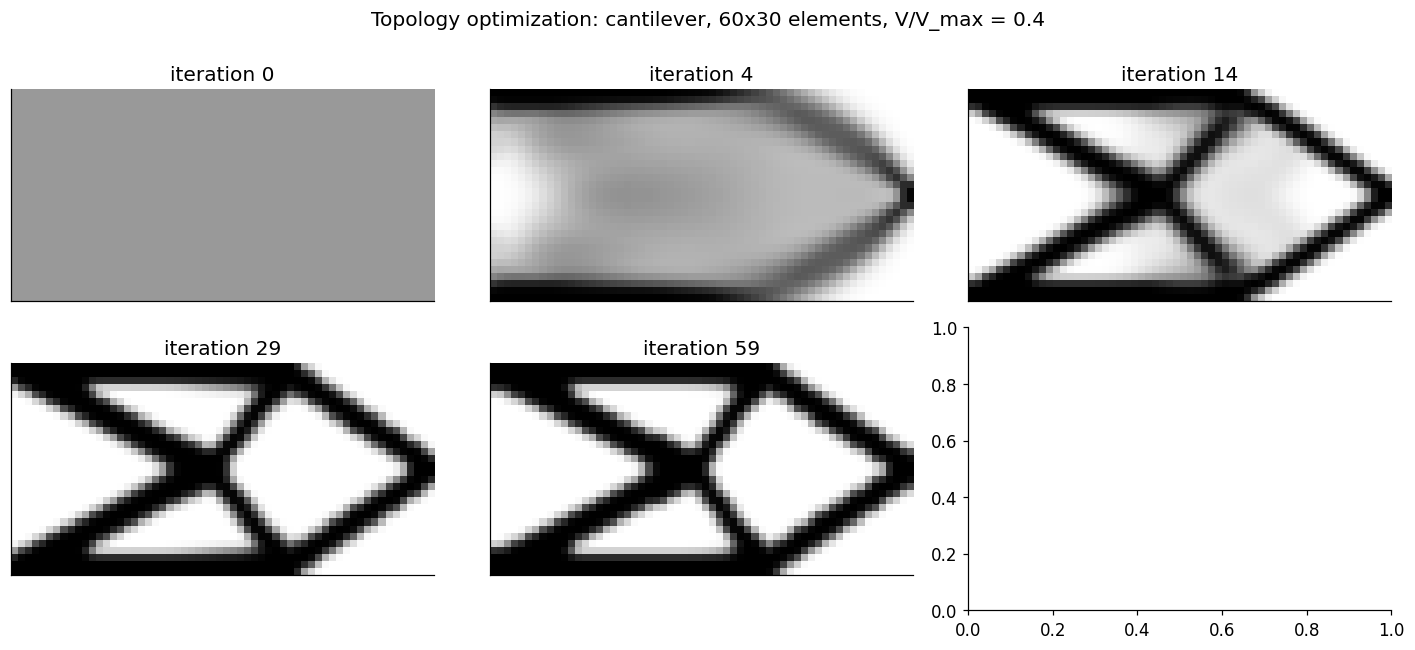

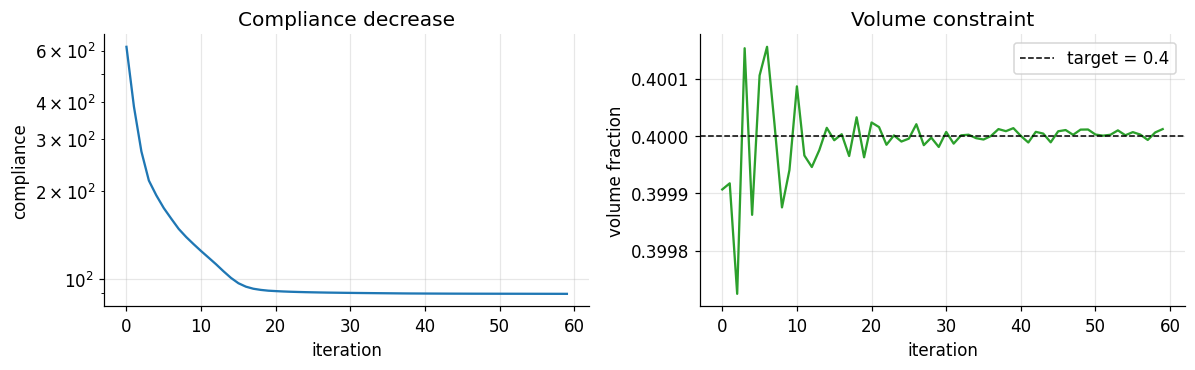

In [5]:
# Plot evolution
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
sorted_iters = sorted(snapshots.keys())[:6]
for ax, it_show in zip(axes.flat, sorted_iters):
    ax.imshow(1.0 - snapshots[it_show], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"iteration {it_show}")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Topology optimization: cantilever, {nelx}x{nely} elements, V/V_max = {volume_frac}")
plt.tight_layout(); plt.show()

# Plot convergence
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].semilogy(history["compliance"])
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("compliance")
ax[0].set_title("Compliance decrease")
ax[0].grid(True, alpha=0.3)

ax[1].plot(history["vol_frac"], "C2")
ax[1].axhline(volume_frac, color="k", ls="--", lw=1, label=f"target = {volume_frac}")
ax[1].set_xlabel("iteration"); ax[1].set_ylabel("volume fraction")
ax[1].set_title("Volume constraint")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout(); plt.show()

**The structure that emerges is unmistakable:** a chord-and-diagonal truss with the upper and
lower chords carrying tension/compression and diagonal bracing transferring shear. This is what
a steel-truss bridge engineer would draw on a napkin — and the optimizer found it from scratch
by following the negative compliance gradient subject to a volume budget.

A few features worth noticing in the convergence:

* Compliance drops by roughly an order of magnitude over 60 iterations and plateaus.
* The volume fraction sticks tightly to the target after iteration ~5; OC's volume-bisection
  loop is enforcing the equality very actively (at the optimum, complementary slackness gives
  $\mu_\mathrm{vol} > 0$, so the constraint *is* tight, not just feasible).
* Intermediate density elements (gray) progressively get pushed to 0 or 1 by SIMP. The final
  design is about 90% binary; the small remaining gray tendrils are sub-element features the
  filter can't resolve.

### Why the filter

Without `density_filter`, the same code converges to a **checkerboard pattern**: alternating
0/1 cells that artificially inflate the apparent stiffness of bilinear FE elements. This is
purely a discretization artifact (the same checkerboard with high-order elements would compute
much lower stiffness). The filter blurs over a small radius $r_\mathrm{min}$, suppressing
features finer than the filter scale. This makes the design *mesh-independent*: refining the
mesh and shrinking $r_\mathrm{min}$ proportionally gives the same continuous design at
higher resolution.

The filter changes the gradient calculation: $c$ depends on the *physical* (filtered) density,
not the *design* (unfiltered) density. Chain rule gives
$\partial c / \partial \rho_\mathrm{design} = H^\top \mathrm{diag}(1/H_s) (\partial c / \partial \rho_\mathrm{phys})$,
which is what we coded.

## 6. The throughline closes

This was the longest single notebook in the series, and it's worth pausing to see how it
unifies everything:

| What we used | Where it came from |
|---|---|
| Adjoint sensitivity for the compliance gradient | Part IV (general adjoint construction) |
| Gradient verified to roundoff vs FD (in principle) | Part IV (verification methodology) |
| KKT stationarity + complementary slackness on the volume inequality | Part VII |
| Active set on the box constraints handled by `clip` in OC | Part VII (active-set methods) |
| Iterative descent with line search analog (move limits) | Part VI (SLSQP) |

What was new in Part VIII:

* The PDE is elliptic (not parabolic as in Part IV's heat equation), so the forward solve is
  one $\mathbf{K}\mathbf{u} = \mathbf{f}$ rather than a time march.
* The cost is **self-adjoint**, giving $\boldsymbol\lambda = -\mathbf{u}$ and zero extra cost
  for the adjoint.
* The number of design variables is large (1800 here, easily $10^5$ in production) — adjoint
  sensitivity is non-negotiable.
* The geometry is structured (regular grid of elements), so all the FE machinery is
  vectorized; the FE solve is the bottleneck (sparse direct).

### What's *not* covered here

* **Multiple load cases.** Real structures must perform under several load combinations.
  Compliance becomes $c = \sum_k w_k \mathbf{f}_k^\top \mathbf{u}_k$ with several adjoints
  (one per load case). MMA handles this naturally.
* **Stress constraints.** "No element may exceed yield stress" is a per-element inequality —
  $n_\mathrm{el}$ multipliers. The standard treatment is **p-norm aggregation** of element
  stresses or active-set methods on the worst few elements.
* **Geometric / manufacturing constraints.** Minimum feature size, casting directions,
  symmetry, additive-manufacturing overhang angles. Each adds inequality constraints with
  their own gradient implications.
* **Nonlinear elasticity.** Geometric and material nonlinearity (large deformation,
  hyperelasticity, plasticity) make the forward problem nonlinear, the adjoint solve
  non-trivial, and convergence harder. Deaton & Grandhi (2014) review the field.
* **Topology + shape.** Once a topology is found, post-process by **shape optimization** to
  smooth element-aligned boundaries into curved ones, often via level-set methods.
  Allaire, Jouve & Toader (2004) is the classic reference.
* **Discrete topology with integer programming.** SIMP is a heuristic; rigorous binary
  optimization via branch-and-bound or sequential linear programming is feasible only on
  small problems. Stolpe (2016) reviews.

### Books worth buying

* M. P. Bendsøe & O. Sigmund, *Topology Optimization: Theory, Methods, and Applications*,
  2nd ed. (Springer, 2003) — the field's textbook.
* O. Sigmund, *A 99-line topology optimization code in MATLAB* (Struct. Multidisc. Optim. 2001)
  — the code that started a thousand variations. Our Python port above is essentially this.
* E. Andreassen, A. Clausen, M. Schevenels, B. S. Lazarov & O. Sigmund,
  *Efficient topology optimization in MATLAB using 88 lines of code* (2011) — the modernized
  version with vectorized assembly, used in production teaching.

## What's now in the toolkit, end-to-end

After all eight parts:

| Part | Topic | Key tool |
|---|---|---|
| I | Forward problems on fixed domains | Fourier / Chebyshev differentiation |
| II | Domain mapping, 2D, KdV, Gibbs | Tensor products, IFRK4, exponential filter |
| III | Stiff time-stepping, fast 2D solvers, unbounded domains | ETDRK4 + contour, fast diag, Hermite |
| IV | Adjoints, sensitivity, inverse problems | Discrete adjoint, Lagrangian gradient |
| V | Eigenvalue and stability problems | Generalized EVP, Orr–Sommerfeld, Floquet |
| VI | Optimal control | LGL transcription + SQP/SNOPT |
| VII | KKT theory, inequality constraints, path-constrained OC | Active set, complementary slackness |
| VIII | Topology optimization | SIMP + adjoint sensitivity + OC + filter |

The throughline: pseudospectral methods are the natural discretization for problems with smooth
solutions on simple geometries; the *adjoint method* is the natural way to compute gradients of
PDE-constrained functionals; the *KKT conditions* are the natural way to handle inequality
constraints; *direct collocation* is the natural way to combine all three for optimal control.
Once you have these four pieces, you have a remarkably general toolkit: the same code shape
solves fluid stability, heat-equation inverse problems, trajectory optimization, and structural
optimization. The differential operator is the same matrix; only the boundary conditions and
the cost functional change.